# Лабораторная работа №3

## Исследование скрытых характеристик сигналов электроэнцефалографии

**Цель задания:** исследование скрытых характеристик сигналов электроэнцефалографии.  
**Ключевой навык:** расчёт спектральной плотности, вейвлет-преобразование.

В работе используется запись **`eeg14.edf`** и таблицы аннотаций **`annotations_2017_A.csv`**, **`annotations_2017_B.csv`**, **`annotations_2017_C.csv`**.

> Важно: запускать notebook нужно **сверху вниз** командой **Run All**, чтобы все переменные и библиотеки были инициализированы корректно.

## 1. Подготовка среды и импорт библиотек

В этой ячейке выполняются импорт библиотек и автоматическая проверка наличия `mne`.  
Если пакет не установлен, notebook попытается установить его в текущую среду Python.

In [1]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("mne") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mne"])

import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, spectrogram, fftconvolve
import mne

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "DejaVu Sans"

print("Python executable:", sys.executable)
print("mne version:", mne.__version__)

Python executable: c:\Users\ALI\AppData\Local\Programs\Python\Python38\python.exe
mne version: 1.6.1


## 2. Загрузка EDF-файла и таблиц аннотаций

Сначала считываем EDF-запись, затем загружаем три таблицы аннотаций.  
Для файла `eeg14.edf` используется столбец **14** в CSV-файлах разметки.

In [2]:
BASE_DIR = Path(".")
edf_path = BASE_DIR / "eeg14.edf"
annA_path = BASE_DIR / "annotations_2017_A.csv"
annB_path = BASE_DIR / "annotations_2017_B.csv"
annC_path = BASE_DIR / "annotations_2017_C.csv"

for p in [edf_path, annA_path, annB_path, annC_path]:
    print(f"{p.name}: {'OK' if p.exists() else 'NOT FOUND'}")

raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
sfreq = float(raw.info["sfreq"])
duration_sec = raw.n_times / sfreq
n_seconds = math.ceil(duration_sec)

file_num = int(re.search(r"(\d+)", edf_path.stem).group(1))

def load_annotation(csv_path, file_number, n_seconds):
    df = pd.read_csv(csv_path)
    col = str(file_number)
    arr = df[col].fillna(0).astype(int).to_numpy()
    return arr[:n_seconds]

ann_a = load_annotation(annA_path, file_num, n_seconds)
ann_b = load_annotation(annB_path, file_num, n_seconds)
ann_c = load_annotation(annC_path, file_num, n_seconds)

print("Частота дискретизации:", sfreq, "Гц")
print("Длительность записи:", duration_sec, "с")
print("Количество каналов:", len(raw.ch_names))
print("Количество секунд в анализе:", n_seconds)

eeg14.edf: OK
annotations_2017_A.csv: OK
annotations_2017_B.csv: OK
annotations_2017_C.csv: OK
Частота дискретизации: 256.0 Гц
Длительность записи: 3726.0 с
Количество каналов: 21
Количество секунд в анализе: 3726


## 3. Определение интервалов приступа по правилу большинства

После объединения аннотаций по правилу большинства было получено 36 приступных интервалов. Первый интервал начинается на 254-й секунде и заканчивается на 278-й секунде. Именно этот момент используется как точка отсчёта для детального анализа сигнала.
Для наглядности ниже показаны исходные аннотации трёх экспертов и итоговая бинарная маска, сформированная по правилу большинства.

Файл: eeg14.edf
Частота дискретизации: 256.0 Гц
Длительность записи: 3726.00 с


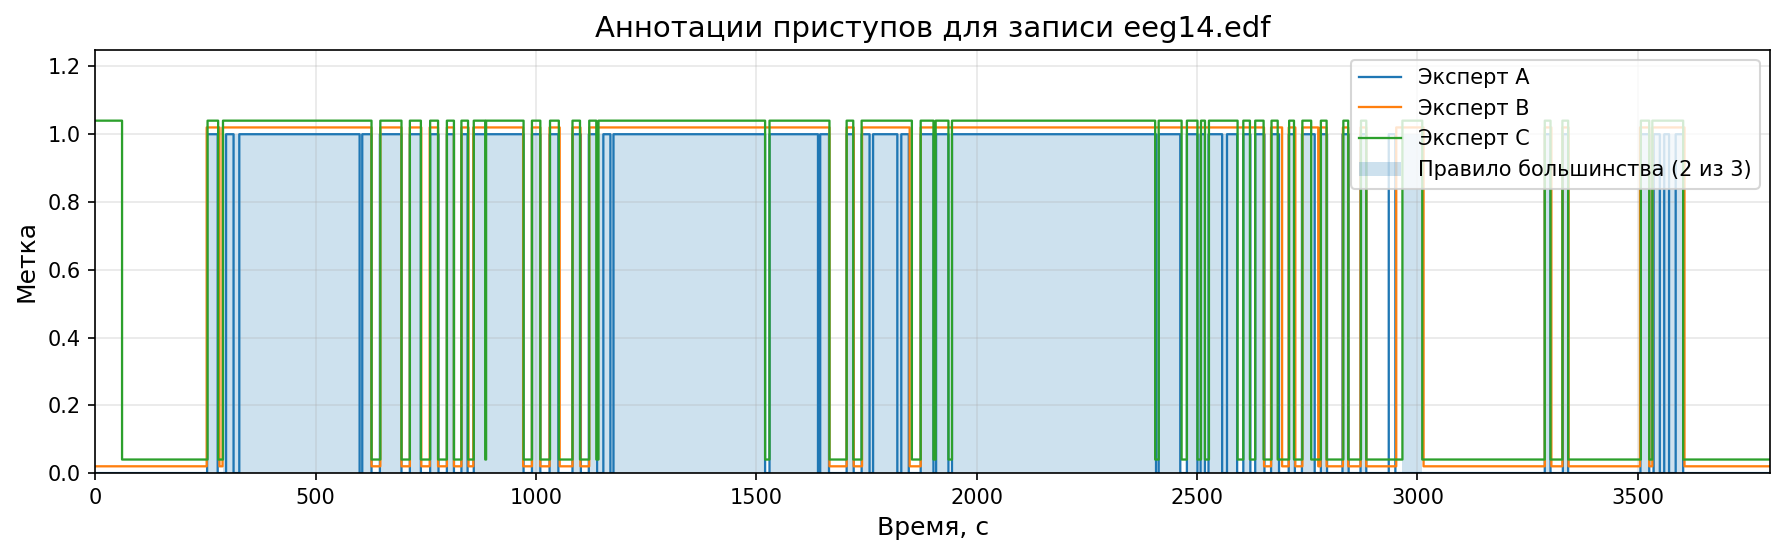

In [3]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

# --------------------------------------------------
# Пути к файлам
# --------------------------------------------------
BASE_DIR = Path.cwd()

edf_path = BASE_DIR / "eeg14.edf"
ann_a_path = BASE_DIR / "annotations_2017_A.csv"
ann_b_path = BASE_DIR / "annotations_2017_B.csv"
ann_c_path = BASE_DIR / "annotations_2017_C.csv"

# --------------------------------------------------
# Определяем номер записи из имени файла
# eeg14.edf -> 14
# --------------------------------------------------
match = re.search(r"(\d+)", edf_path.stem)
if match is None:
    raise ValueError("Не удалось определить номер записи из имени EDF-файла.")

record_num = int(match.group(1))
col_name = str(record_num)

# --------------------------------------------------
# Загружаем EDF только для проверки
# --------------------------------------------------
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="ERROR")
print(f"Файл: {edf_path.name}")
print(f"Частота дискретизации: {raw.info['sfreq']} Гц")
print(f"Длительность записи: {raw.n_times / raw.info['sfreq']:.2f} с")

# --------------------------------------------------
# Загружаем аннотации трёх экспертов
# --------------------------------------------------
ann_a_df = pd.read_csv(ann_a_path)
ann_b_df = pd.read_csv(ann_b_path)
ann_c_df = pd.read_csv(ann_c_path)

ann_a = ann_a_df[col_name].fillna(0).astype(int).to_numpy()
ann_b = ann_b_df[col_name].fillna(0).astype(int).to_numpy()
ann_c = ann_c_df[col_name].fillna(0).astype(int).to_numpy()

# выравнивание длины
n = min(len(ann_a), len(ann_b), len(ann_c))
ann_a = ann_a[:n]
ann_b = ann_b[:n]
ann_c = ann_c[:n]

# правило большинства: 2 из 3
majority = ((ann_a + ann_b + ann_c) >= 2).astype(int)

# временная ось
time_sec = np.arange(n)

# --------------------------------------------------
# Небольшой вертикальный сдвиг линий, чтобы они не сливались
# --------------------------------------------------
y_a = ann_a + 0.00
y_b = ann_b + 0.02
y_c = ann_c + 0.04

# --------------------------------------------------
# Построение графика
# --------------------------------------------------
plt.figure(figsize=(12, 3.8))

plt.step(time_sec, y_a, where="post", linewidth=1.1, label="Эксперт A")
plt.step(time_sec, y_b, where="post", linewidth=1.1, label="Эксперт B")
plt.step(time_sec, y_c, where="post", linewidth=1.1, label="Эксперт C")

plt.fill_between(
    time_sec,
    0,
    1.0,
    where=(majority == 1),
    step="post",
    alpha=0.22,
    label="Правило большинства (2 из 3)"
)

plt.title(f"Аннотации приступов для записи {edf_path.name}", fontsize=14)
plt.xlabel("Время, с", fontsize=12)
plt.ylabel("Метка", fontsize=12)

plt.xlim(0, 3800)
plt.ylim(0, 1.25)

plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

В датасете доступны три независимые аннотации экспертов.  
Чтобы получить устойчивую итоговую разметку, применим правило **большинства 2 из 3**: если хотя бы два эксперта отмечают приступ в одну и ту же секунду, считаем эту секунду относящейся к приступу.

In [4]:
majority = ((ann_a + ann_b + ann_c) >= 2).astype(int)

def find_runs(arr):
    arr = np.asarray(arr).astype(int)
    d = np.diff(np.r_[0, arr, 0])
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0] - 1
    return [(int(s), int(e), int(e - s + 1)) for s, e in zip(starts, ends)]

runs = find_runs(majority)
runs_df = pd.DataFrame(runs, columns=["Начало, с", "Конец, с", "Длительность, с"])

print("Количество интервалов приступа по правилу большинства:", len(runs))
runs_df.head(10)

Количество интервалов приступа по правилу большинства: 36


,"Начало, с","Конец, с","Длительность, с"
0,254,278,25
1,290,626,337
2,647,694,48
3,714,738,25
4,760,777,18
5,798,813,16
6,831,845,15
7,859,971,113
8,991,1009,19
9,1031,1051,21


Для дальнейшего анализа используется **первый интервал приступа**, так как он даёт наглядный локальный фрагмент записи.  
По правилу большинства этот интервал начинается на **254-й секунде** и заканчивается на **278-й секунде**.

Первый интервал приступа: (254, 278, 25)


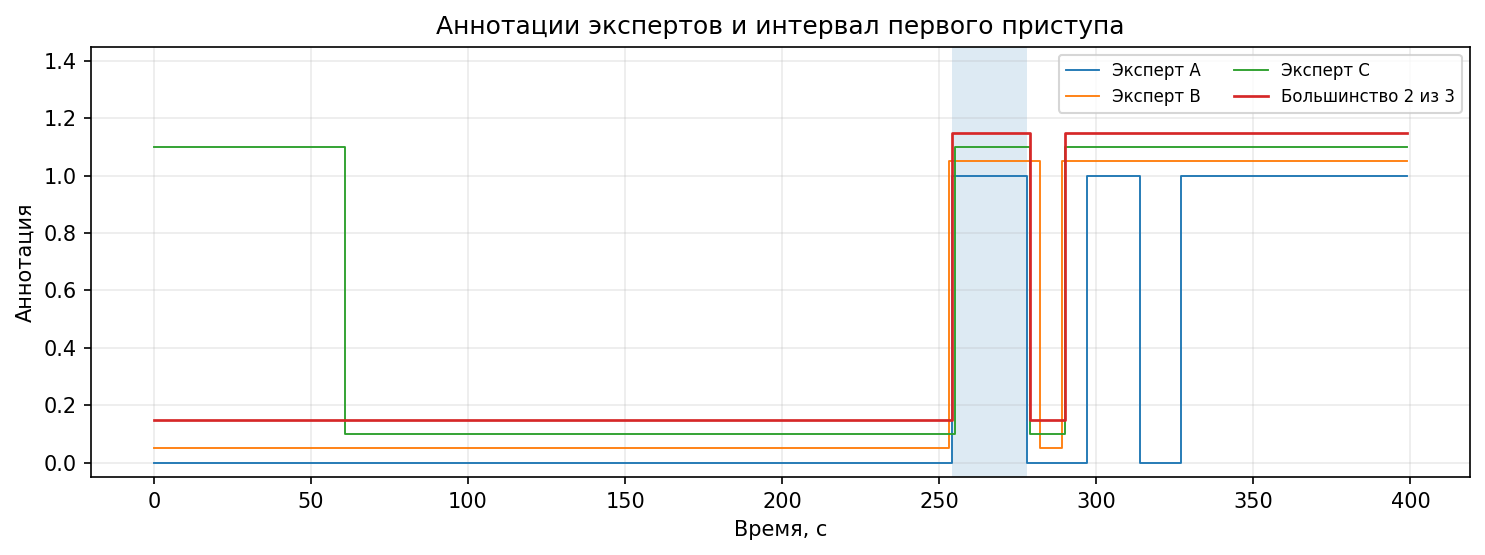

In [5]:
first_run = runs[0]
first_start, first_end, first_len = first_run
print("Первый интервал приступа:", first_run)

time_sec = np.arange(n_seconds)
view_end = 400

plt.figure(figsize=(10, 3.8))
plt.step(time_sec[:view_end], ann_a[:view_end], where="post", label="Эксперт A", linewidth=0.9)
plt.step(time_sec[:view_end], ann_b[:view_end] + 0.05, where="post", label="Эксперт B", linewidth=0.9)
plt.step(time_sec[:view_end], ann_c[:view_end] + 0.10, where="post", label="Эксперт C", linewidth=0.9)
plt.step(time_sec[:view_end], majority[:view_end] + 0.15, where="post", label="Большинство 2 из 3", linewidth=1.3)
plt.axvspan(first_start, first_end, alpha=0.15)
plt.ylim(-0.05, 1.45)
plt.xlabel("Время, с")
plt.ylabel("Аннотация")
plt.title("Аннотации экспертов и интервал первого приступа")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Выбор EEG-каналов и усреднение по всем каналам

По условию задания нужно получить один усреднённый сигнал:
1. взять все EEG-каналы;
2. сложить их;
3. разделить на количество каналов.

Именно этот усреднённый сигнал затем используется во всех дальнейших преобразованиях.

In [6]:
eeg_channels = [ch for ch in raw.ch_names if ch.startswith("EEG")]
data_uv = raw.get_data(picks=eeg_channels) * 1e6  # перевод в микровольты
avg_signal = data_uv.mean(axis=0)

print("EEG-каналы:", len(eeg_channels))
print("Первые каналы:", eeg_channels[:5])
print("Размер усреднённого сигнала:", avg_signal.shape)

EEG-каналы: 19
Первые каналы: ['EEG Fp1-Ref', 'EEG Fp2-Ref', 'EEG F3-Ref', 'EEG F4-Ref', 'EEG F7-Ref']
Размер усреднённого сигнала: (953856,)


## 5. График временной зависимости усреднённого сигнала в области приступа

Для наглядности возьмём окно немного шире самого приступа: от **245 с** до **340 с**.  
Так видно не только сам эпизод, но и поведение сигнала непосредственно до и после него.

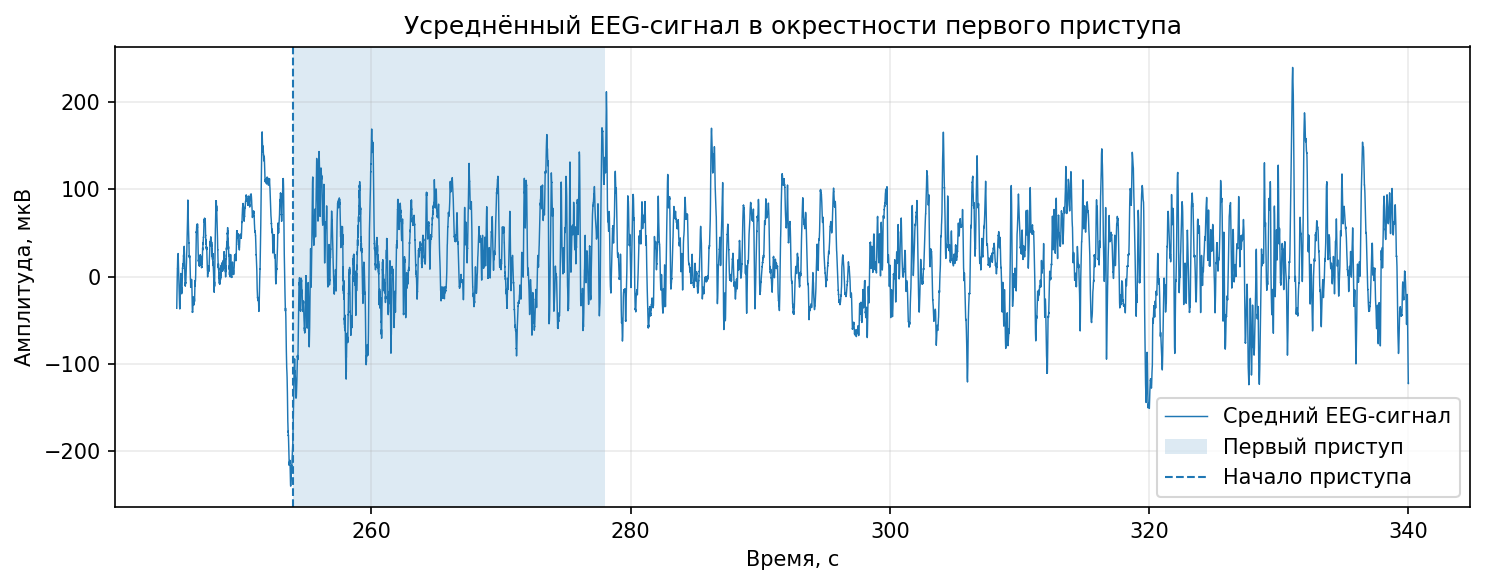

In [7]:
t0, t1 = 245, 340
i0, i1 = int(t0 * sfreq), int(t1 * sfreq)

seg_t = np.arange(i0, i1) / sfreq
seg_raw = avg_signal[i0:i1]

plt.figure(figsize=(10, 4))
plt.plot(seg_t, seg_raw, linewidth=0.7, label="Средний EEG-сигнал")
plt.axvspan(first_start, first_end, alpha=0.15, label="Первый приступ")
plt.axvline(first_start, linestyle="--", linewidth=1.0, label="Начало приступа")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда, мкВ")
plt.title("Усреднённый EEG-сигнал в окрестности первого приступа")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Удаление частот выше 60 Гц

Для выполнения требования задания используем **НЧ-фильтр Баттерворта 4-го порядка** с частотой среза 60 Гц.  
После фильтрации дополнительно построим сравнительный график, чтобы увидеть отличия между исходным и преобразованным сигналом.

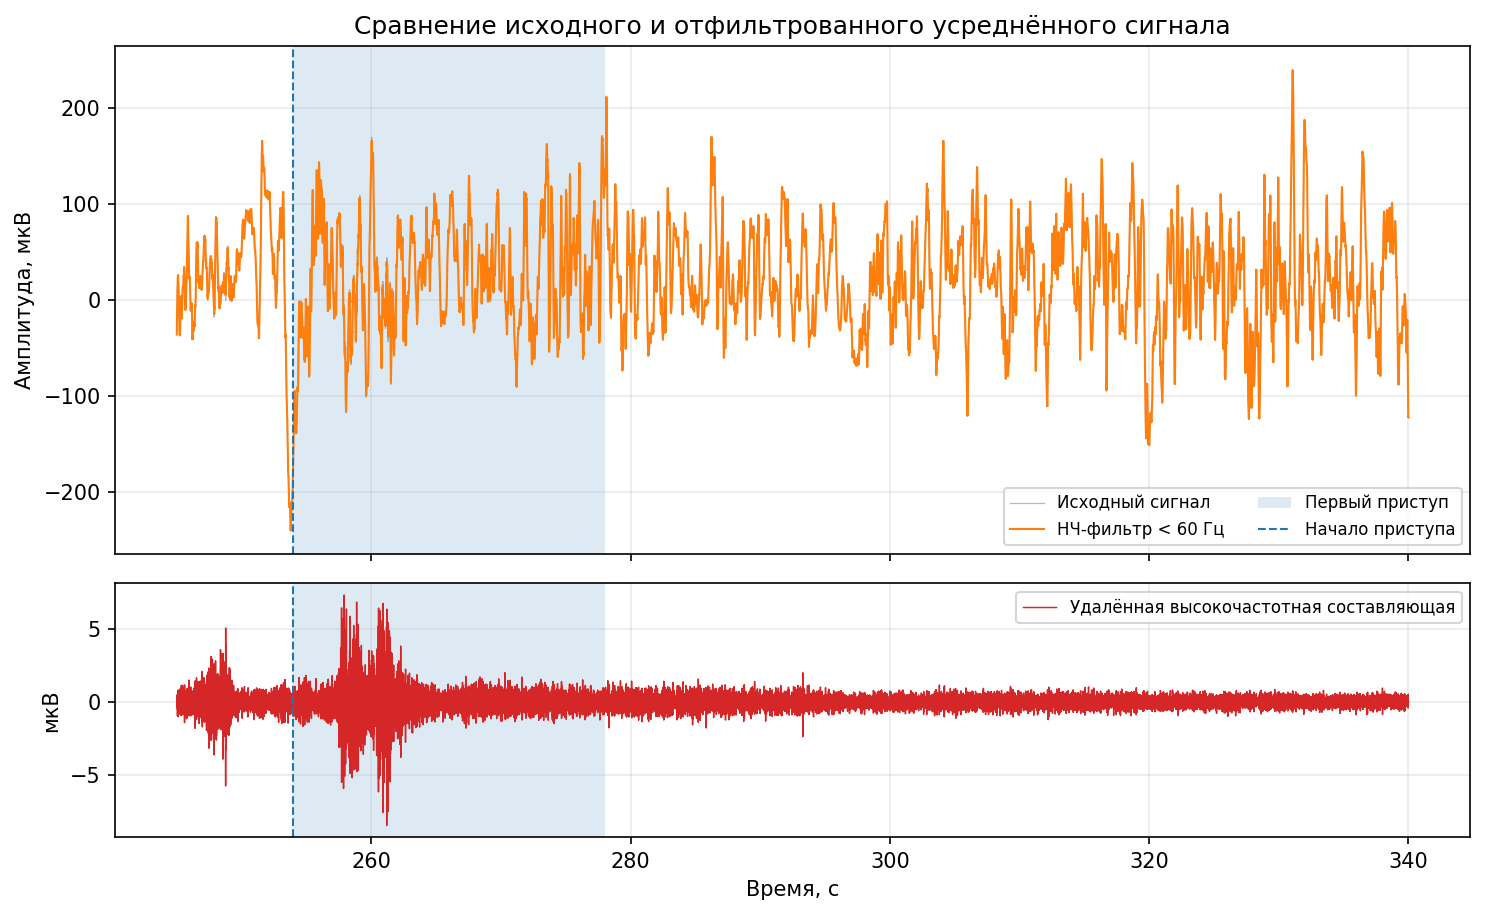

In [8]:
b, a = butter(4, 60 / (sfreq / 2), btype="low")
avg_filtered = filtfilt(b, a, avg_signal)
seg_filt = avg_filtered[i0:i1]
hf_component = seg_raw - seg_filt

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6.2), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

axes[0].plot(seg_t, seg_raw, linewidth=0.6, alpha=0.45, label="Исходный сигнал")
axes[0].plot(seg_t, seg_filt, linewidth=1.0, label="НЧ-фильтр < 60 Гц")
axes[0].axvspan(first_start, first_end, alpha=0.15, label="Первый приступ")
axes[0].axvline(first_start, linestyle="--", linewidth=1.0, label="Начало приступа")
axes[0].set_ylabel("Амплитуда, мкВ")
axes[0].set_title("Сравнение исходного и отфильтрованного усреднённого сигнала")
axes[0].legend(ncol=2, fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(seg_t, hf_component, linewidth=0.7, color="tab:red", label="Удалённая высокочастотная составляющая")
axes[1].axvspan(first_start, first_end, alpha=0.15)
axes[1].axvline(first_start, linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Время, с")
axes[1].set_ylabel("мкВ")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Спектрограмма отфильтрованного сигнала

Спектрограмма позволяет увидеть, как распределяется мощность сигнала по времени и частоте.  
Так как высокие частоты уже удалены, отображаем диапазон только до **60 Гц**.

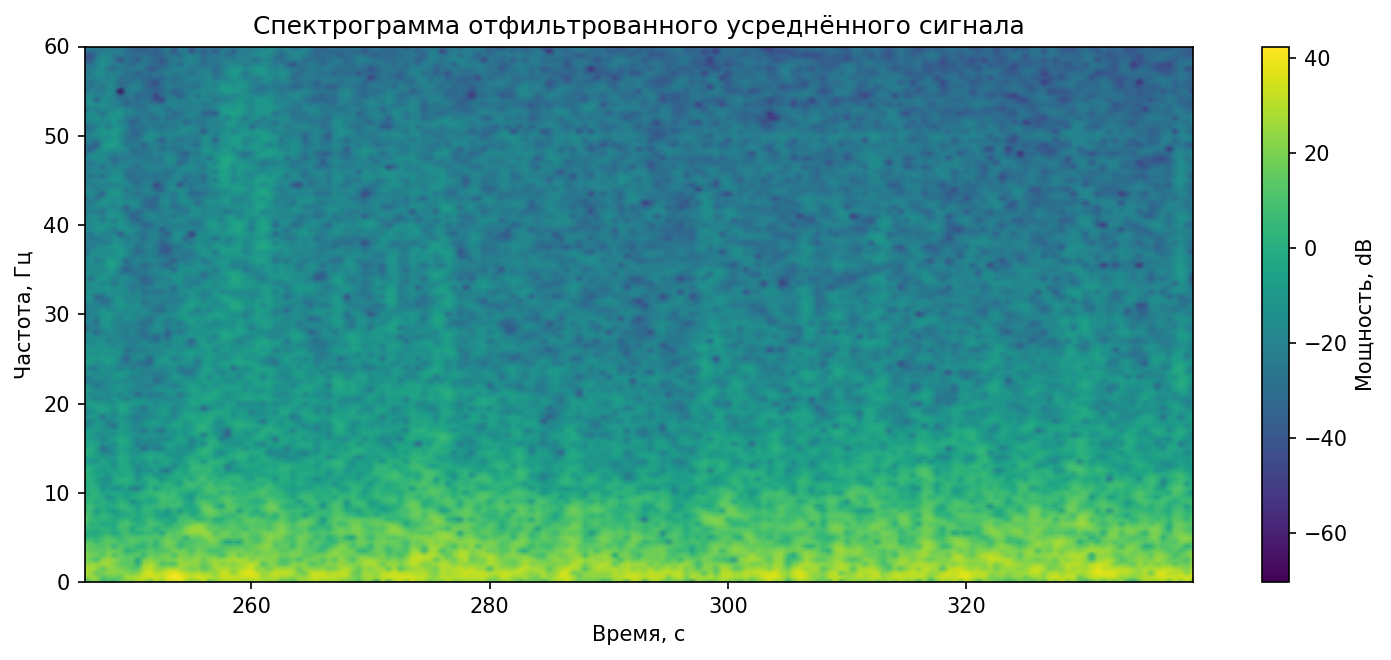

In [9]:
spec_f, spec_t, Sxx = spectrogram(
    seg_filt,
    fs=sfreq,
    window="hann",
    nperseg=512,
    noverlap=384,
    scaling="density",
    mode="psd"
)

mask = spec_f <= 60

plt.figure(figsize=(10, 4.5))
plt.pcolormesh(
    spec_t + t0,
    spec_f[mask],
    10 * np.log10(Sxx[mask] + 1e-12),
    shading="gouraud",
    cmap="viridis"
)
plt.ylim(0, 60)
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.title("Спектрограмма отфильтрованного усреднённого сигнала")
cbar = plt.colorbar()
cbar.set_label("Мощность, dB")
plt.tight_layout()
plt.show()

## 8. Вейвлет-преобразование (скейлограмма)

Для анализа локальных изменений сигнала во времени используется **комплексное вейвлет-преобразование Морле**.  
Скейлограмма показывает эволюцию мощности в диапазоне частот от 1 до 60 Гц.

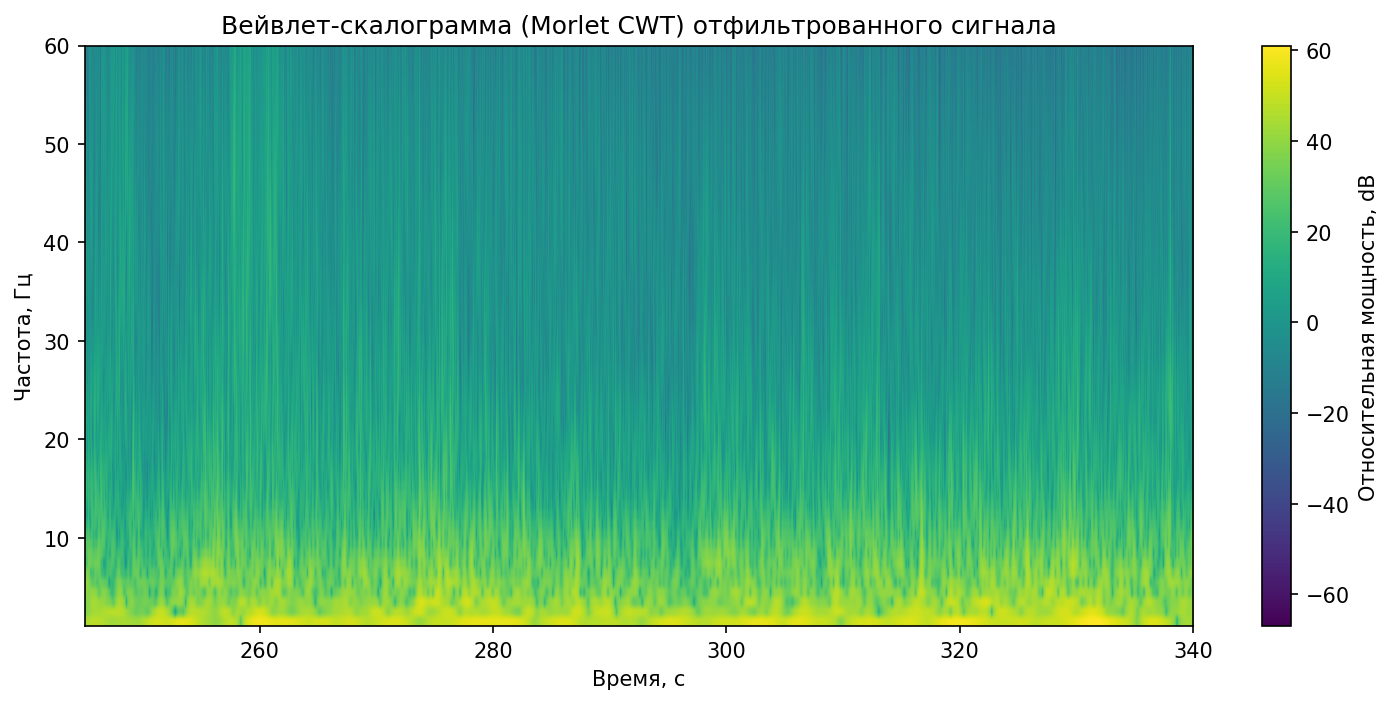

In [10]:
def morlet_cwt(x, sfreq, freqs, n_cycles=6):
    out = np.zeros((len(freqs), len(x)), dtype=np.complex128)
    for k, f in enumerate(freqs):
        sigma_t = n_cycles / (2 * np.pi * f)
        half = int(np.ceil(4 * sigma_t * sfreq))
        tt = np.arange(-half, half + 1) / sfreq
        wavelet = np.exp(2j * np.pi * f * tt) * np.exp(-(tt ** 2) / (2 * sigma_t ** 2))
        wavelet /= np.sqrt(np.sum(np.abs(wavelet) ** 2))
        out[k] = fftconvolve(x, np.conj(wavelet[::-1]), mode="same")
    return out

freqs = np.linspace(1, 60, 60)
coef = morlet_cwt(seg_filt, sfreq, freqs, n_cycles=6)
power = np.abs(coef) ** 2

plt.figure(figsize=(10, 4.8))
plt.imshow(
    10 * np.log10(power + 1e-9),
    aspect="auto",
    origin="lower",
    extent=[t0, t1, freqs[0], freqs[-1]],
    cmap="viridis"
)
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.title("Вейвлет-скалограмма (Morlet CWT) отфильтрованного сигнала")
cbar = plt.colorbar()
cbar.set_label("Относительная мощность, dB")
plt.tight_layout()
plt.show()

## 9. Вывод

1. По аннотациям трёх экспертов для записи `eeg14.edf` был определён первый интервал приступа: **254–278 с**.
2. Из всех EEG-каналов был сформирован один усреднённый сигнал.
3. Для этого сигнала удалены все частоты выше **60 Гц** с помощью НЧ-фильтра.
4. Построены:
   - график временной зависимости сигнала в момент приступа;
   - сравнительный график исходного и отфильтрованного сигнала;
   - спектрограмма;
   - вейвлет-скалограмма.
5. Полученные представления позволяют исследовать скрытые временно-частотные характеристики ЭЭГ в области приступа.